# <center> IIIT Vadodara </center>
## <center> Winter 2024-25 </center>
## <center> CS/IT 308, CS 652, CS8XX Machine Learning Lab </center>
## <center> Lab#5 Logistic regression for clasification </center>

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from scipy import misc
from numpy import linalg as la
import matplotlib.image as mpimg
import glob
from numpy import linalg as LA
import scipy.io as sio

## <font color='yellow'> Brief about **Gradient descent optimization**:
---


Given a system $Ax=b$, we find $x$ for given observations $b$ and coeffiecient matrix $A$. When $b$ is not in column space of $A$, then $Ax \neq b$ and we need to find $x$ in such a way that $Ax \approx b$.

<br>
Linear least square is one of the methods to estimate $x$ by minimizing the mean square error as, $\min ||Ax-b||_2$. This can be written as,
        
$\underset{x}{\mathrm{argmin}}||Ax-b||_{2}^{2} = f(x)$

We need to find $x$ in such a way that $f(x)$ will be minimum in $L_2$ norm.

<br>


We will solve this by applying gradient descent algortithm on $f(x)$.
<br>
To apply this algorithm we need to find gradient of the function, i.e.,
<br>
              $\Delta_x f(x)= A^T(Ax-b) = A^TAx-A^Tb$

<br>


Optimisation for least-squares
<br>
$||A^TAx-A^Tb||_2>\delta$, $\delta$ is the small positive number indicating tolerance.

<br>

Now we will find new x iteratively using step size $\alpha$ to find the best fit for $AX=b$ as:

<br>
$x^{[n+1]}=x^{[n]}-\alpha (A^TAx-A^Tb)$.
<br>

We need to choose $\alpha$, $\delta$ and $x^{[0]}$ to iterate until $x^{[n+1]} \rightarrow x^{[n]}$.

## <font color='red'> **Problem 1)**
Consider $A=\begin{bmatrix}
0.7 & 0.2\\
0.1 & 0.6
\end{bmatrix}$ and the observation matrix $b=\begin{bmatrix}
0.5\\
0.6
\end{bmatrix}$ in a system $Ax=b$. However, $b$ is not in column space of $A$, thus $Ax \neq b$ and we need to find $x$ in such a way that $Ax \approx b$. Using linear least square $x$ can be estimated by minimizing the mean squared error as,  $\min ||Ax-b||_2$. Use gradient descent optimization to minimize the functional and obtain estimated value of $x$, i.e., $\hat{x}_{gd-opt}$.


Now, find out $\hat{x}$ using psuedoinverse or normal equation, i.e., $\hat{x}_{pinv}$. Check, is  $\hat{x}_{pinv}$ = $\hat{x}_{gd-opt}$? Yes/No, comment.



In [10]:
import numpy as np
# Define the coefficient matrix A and the observation vector b
A=np.array([[0.7,0.2],[0.1,0.6]])
b=np.array([[0.5],[0.6]])
learning_rate=0.01
tolerance=1e-6
max_iters=1000
x_gd=np.zeros((2,1))
for iteration in range(max_iters):
    gradient=A.T@(A@x_gd-b)
    x_new=x_gd-learning_rate*gradient
    if np.linalg.norm(x_new-x_gd,ord=2)<tolerance:
        print(f"Converged after{iteration+1}iterations")
        break
    x_gd=x_new
x_gd_opt=x_gd
x_pinv=np.linalg.pinv(A)@b
solutions_match=np.allclose(x_gd_opt,x_pinv,atol=1e-3)
print("Gradient Descent Optimized Solution:")
print(x_gd_opt)
print("\nPseudoinverse Solution:")
print(x_pinv)
print("\nDo the solutions match?","Yes" if solutions_match else"No")


Gradient Descent Optimized Solution:
[[0.47321145]
 [0.89319428]]

Pseudoinverse Solution:
[[0.45 ]
 [0.925]]

Do the solutions match? No


##  <font color='yellow'> Logistic regression

---
Cost funcion for logistic regression,
$$
\begin{aligned}
J(\theta) &=\frac{1}{m} \sum_{i=1}^{m} \cos t\left(h_{\theta}\left(x^{i}\right), y^{\prime}\right) \\
&=-\frac{1}{m}\left[\sum_{i=1}^{m} y^{i} \log h_{\theta}\left(x^{i}\right)+\left(1-y^{i}\right)\right.\log \left(1-\log \left(x^{i}\right)\right]\\
h(x)&=\frac{1}{1+e^{-\Theta^Tx}}
\end{aligned}
$$
So, using gradient descent
$$
\Theta_{i+1}=\Theta_{i}-\frac{\alpha}{m} \sum_{i=1}^{m}\left(h\left(x^{i} \Theta\right)-y^{i}\right)
$$
iterate till $$
\Theta_{i+1} \cong \Theta_{i}
$$




## <font color='red'> Problem 2) Perform logistic regression on the dataset given below.
Here, to classify 2D data,
decision line can be given as,
$$\theta_0+\theta_1x+\theta_2y=0$$
Let, $$\Theta^T=\begin{bmatrix}
\theta_0\\
\theta_1\\
\theta_2
\end{bmatrix}$$

In [ ]:
# Dataset example
X = np.array([[0,0,0],[0,1,0],[0,2,0],[0,3,1],[1,0,0],[1,1,0],[1,2,1],[1,3,1],[2,0,0],[2,1,1],[2,2,1],[2,3,1]])
Xb = X

print("x1|x2|y") #here x1 and x2 are your 2D data points and y is your class label
print(Xb)

x1|x2|y
[[0 0 0]
 [0 1 0]
 [0 2 0]
 [0 3 1]
 [1 0 0]
 [1 1 0]
 [1 2 1]
 [1 3 1]
 [2 0 0]
 [2 1 1]
 [2 2 1]
 [2 3 1]]


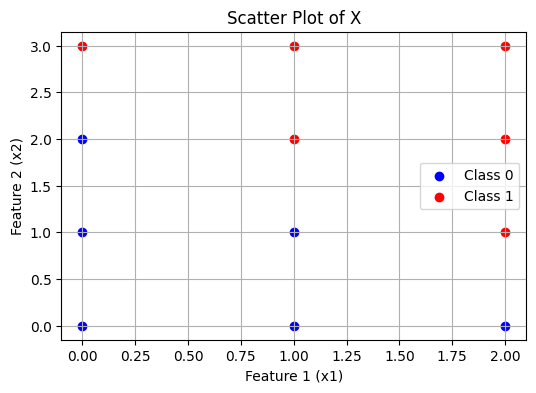

In [12]:
# Generate scatter plot of X
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0,0,0],[0,1,0],[0,2,0],[0,3,1],
    [1,0,0],[1,1,0],[1,2,1],[1,3,1],
    [2,0,0],[2,1,1],[2,2,1],[2,3,1]
])
x1=X[:,0]
x2=X[:,1]
y=X[:,2]
plt.figure(figsize=(6,4))
plt.scatter(x1[y==0],x2[y==0],color='blue',label='Class 0')
plt.scatter(x1[y==1],x2[y==1],color='red',label='Class 1')
# Labels and legend
plt.xlabel('Feature 1 (x1)')
plt.ylabel('Feature 2 (x2)')
plt.title('Scatter Plot of X')
plt.legend()
plt.grid(True)

plt.show()



In [14]:
# Generate X by concatinating ones and X
import numpy as np
X_original=np.array([
    [0,0],[0,1],[0,2],[0,3],
    [1,0],[1,1],[1,2], [1,3],
    [2,0],[2,1],[2,2], [2,3]
])
y=np.array([0,0,0,1,0,0,1,1,0,1,1,1])
ones_col=np.ones((X_original.shape[0], 1))
X=np.hstack((ones_col, X_original))
print("Shape of X with bias column:",X.shape)
print(X)
print("\nLabels (y):",y)



Shape of X with bias column: (12, 3)
[[1. 0. 0.]
 [1. 0. 1.]
 [1. 0. 2.]
 [1. 0. 3.]
 [1. 1. 0.]
 [1. 1. 1.]
 [1. 1. 2.]
 [1. 1. 3.]
 [1. 2. 0.]
 [1. 2. 1.]
 [1. 2. 2.]
 [1. 2. 3.]]

Labels (y): [0 0 0 1 0 0 1 1 0 1 1 1]


In [16]:
# Write code for gradient descent to find thetas
import numpy as np
def gradient_descent(X,y,theta,learning_rate=0.01,iterations=1000,tolerance=1e-6):
    m = len(y)
    for i in range(iterations):
        predictions=X.dot(theta)
        errors=predictions-y
        gradient=(X.T.dot(errors))/m
        new_theta=theta-learning_rate*gradient
        if np.linalg.norm(new_theta-theta,ord=2)<tolerance:
            print(f"Convergence reached after {i+1} iterations.")
            theta=new_theta
            break
        theta=new_theta
    return theta
features=np.array([
    [2],
    [3],
    [4],
    [5]
])
ones_column=np.ones((features.shape[0], 1))
X=np.hstack((ones_column,features))
y=np.array([[7],
              [6],
              [5],
              [4]])
initial_theta=np.zeros((X.shape[1], 1))
optimized_theta=gradient_descent(X,y,initial_theta,learning_rate=0.01,iterations=1000,tolerance=1e-6)
print("Optimized theta values:")
print(optimized_theta)




Optimized theta values:
[[ 5.35883688]
 [-0.04989114]]


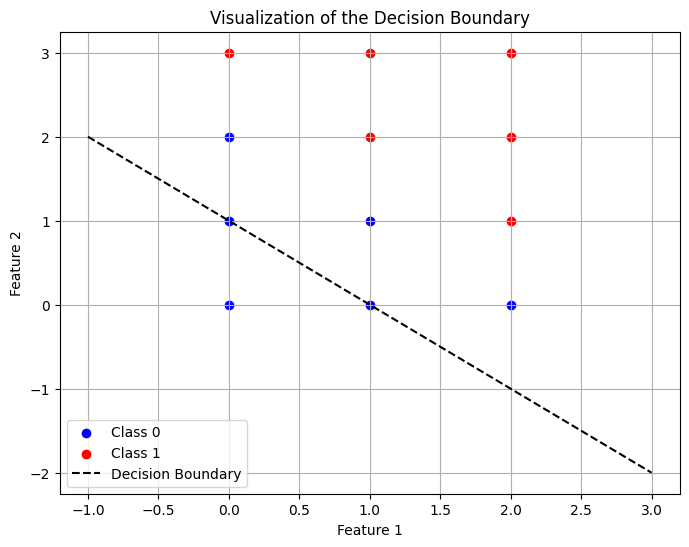

In [19]:
# Plot decision boundry
import numpy as np
import matplotlib.pyplot as plt
data=np.array([
    [0,0,0],
    [0,1,0],
    [0,2,0],
    [0,3,1],
    [1,0,0],
    [1,1,0],
    [1,2,1],
    [1,3,1],
    [2,0,0],
    [2,1,1],
    [2,2,1],
    [2,3,1]
])

features=data[:,:2]
labels=data[:,2]
num_samples=features.shape[0]
features_with_bias=np.hstack((np.ones((num_samples,1)),features))
theta=np.array([[-1.0],[1.0],[1.0]])
plt.figure(figsize=(8,6))
plt.scatter(features[labels==0,0],features[labels==0,1],color='blue',label='Class 0')
plt.scatter(features[labels==1,0],features[labels==1,1],color='red',label='Class 1')
x1_range=np.linspace(features[:,0].min()-1,features[:,0].max()+1,100)
if theta[2]!=0:
    x2_range=-(theta[0]+theta[1]*x1_range)/theta[2]
    plt.plot(x1_range,x2_range,'k--',label='Decision Boundary')
else:
    vertical_line=-theta[0]/theta[1]
    plt.axvline(x=vertical_line,color='k',linestyle='--',label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Visualization of the Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()




In [23]:

num_samples=features.shape[0]
features_with_bias=np.hstack((np.ones((num_samples,1)), features))
theta=np.array([[-1.0], [1.0], [1.0]])
z=features_with_bias.dot(theta)
predicted_labels=(z >= 0).astype(int)
num_correct=np.sum(predicted_labels.flatten()==labels)
accuracy=(num_correct/num_samples)*100
print("Predicted Labels:",predicted_labels.flatten())
print("Actual Labels:",labels)
print(f"Accuracy:{accuracy:.2f}%")


Predicted Labels: [0 1 1 1 1 1 1 1 1 1 1 1]
Actual Labels: [0 0 0 1 0 0 1 1 0 1 1 1]
Accuracy:58.33%
